# Классификатор ирисов

Создадим нейросеть на основе линейной алгебры, для классификации ирисов


## Модель

In [1]:
import numpy as np

In [2]:
INPUT_DIM = 4
OUTPUT_DIM = 3
H_DIM = 10

In [3]:
x = np.array([7.9, 3.1, 7.5, 1.8])

W1 = np.array([[-0.77978227, -1.15673227, -1.75101301, -1.43805527,  0.20081753,
        -0.72199929, -1.42661453, -1.43937179,  1.74795799,  0.63468998],
       [-0.08834675,  0.02176942, -2.42569773,  0.50585698,  0.36123228,
         0.08941554,  0.26185892, -0.42696486,  0.05857806, -0.80264167],
       [-0.629911  ,  0.60489644, -2.53274462,  1.14786567,  0.30626365,
        -0.5113844 ,  0.28649336,  0.24023137, -0.9420087 ,  1.2498354 ],
       [ 0.8307905 ,  0.33661246, -0.18753853, -0.57183749, -0.76546683,
        -1.49455084, -1.26012137,  0.33702109, -0.86596573,  1.0183546 ]])

b1 = np.array([[-0.76824527, -0.70717414, -0.56572409, -1.34290533, -0.48100754,
        -0.46216156,  0.15158831, -1.18178345,  0.59266598, -1.57659416]])

W2 = np.array([[-1.1321912 , -1.09861826,  0.5666117 , -0.33583412],
       [-0.77813484, -0.79113118,  0.38027927, -0.91568549],
       [-0.86827071,  0.3620901 , -1.16111764, -0.77469401],
       [-0.87010906,  0.21461572, -0.74825387, -0.3192252 ],
       [-0.49475613, -0.5701393 , -0.89874864,  0.05536785],
       [-0.5670562 ,  0.65693059,  0.12939742, -1.27263713],
       [-0.57643659, -0.70155653,  0.29340173, -0.34470946],
       [-0.96401653, -0.27600899,  0.33080699, -0.13850356],
       [ 1.15068407,  0.55559094, -1.02538984, -0.18018337],
       [-0.86632953,  0.38102471,  1.59513248, -0.42492802]])

b2 = np.array([[ 0.0221141 , -0.18518566, -0.13017895, -0.3543131 ]])

In [4]:
def relu(t):
    return np.maximum(t, 0)

In [5]:
def softmax(t):
    out = np.exp(t)
    return out / np.sum(out)

In [6]:
def predict(x):
    t1 = x @ W1 + b1
    h1 = relu(t1)
    t2 = h1 @ W2 + b2
    z = softmax(t2)
    return z

In [7]:
probs = predict(x)
pred_class = np.argmax(probs)
class_name = ['Setosa', 'Versicolor', 'Virginica']
print(f"Predicted class: {class_name[pred_class]}")

Predicted class: Virginica


## Обучение

In [ ]:
import random
import numpy as np

In [ ]:
from sklearn import datasets

iris = datasets.load_iris()
dataset = [(iris.data[i][None, ...], iris.target[i]) for i in range(len(iris.target))]

In [ ]:
INPUT_DIM = 4
OUTPUT_DIM = 4
H_DIM = 10

ALPHA = 0.0002
NUM_EPOCHS = 400
BATCH_SIZE = 50

loss_arr = []

In [ ]:
W1 = np.random.randn(INPUT_DIM, H_DIM)
b1 = np.random.randn(1, H_DIM)
W2 = np.random.randn(H_DIM, OUTPUT_DIM)
b2 = np.random.randn(1, OUTPUT_DIM)

W1 = (W1 - 0.5) * 2 * np.sqrt(1 / INPUT_DIM)
b1 = (b1 - 0.5) * 2 * np.sqrt(1 / INPUT_DIM)
W2 = (W2 - 0.5) * 2 * np.sqrt(1 / H_DIM)
b2 = (b2 - 0.5) * 2 * np.sqrt(1 / H_DIM)

In [ ]:
def softmax(t):
    out = np.exp(t)
    return out / np.sum(out)

In [ ]:
def relu(t):
    return np.maximum(t, 0)

In [ ]:
def sparse_cross_entropy(z, y):
    return -np.log(z[0, y])

In [ ]:
def to_full(y, num_classes):
    y_full = np.zeros((1, num_classes))
    y_full[0, y] = 1
    return y_full

In [ ]:
def relu_deriv(t):
    return (t >= 0).astype(float)

In [ ]:
def predict(x):
    t1 = x @ W1 + b1
    h1 = relu(t1)
    t2 = h1 @ W2 + b2
    z = softmax(t2)
    return z

In [ ]:
def calc_accuracy():
    correct = 0
    for x, y in dataset:
        z = predict(x)
        y_pred = np.argmax(z)
        if y_pred == y:
            correct += 1
    acc = correct / len(dataset)
    return acc

In [ ]:
def softmax_batch(t):
    out = np.exp(t)
    return out / np.sum(out, axis=1, keepdims=True)

In [ ]:
def sparse_cross_entropy_batch(z, y):
    return -np.log(np.array([z[j, y[j]] for j in range(len(y))]))

In [ ]:
def to_full_batch(y, num_classes):
    y_full = np.zeros((len(y), num_classes))
    for j, yj in enumerate(y):
        y_full[j, yj] = 1
    return y_full

In [ ]:
for ep in range(NUM_EPOCHS):

    random.shuffle(dataset)

    for i in range(len(dataset) // BATCH_SIZE):

        batch_x, batch_y = zip(*dataset[i * BATCH_SIZE:i * BATCH_SIZE + BATCH_SIZE])
        x = np.concatenate(batch_x, axis=0)
        y = np.array(batch_y)

        # Forward
        t1 = x @ W1 + b1
        h1 = relu(t1)
        t2 = h1 @ W2 + b2
        z = softmax_batch(t2)
        E = np.sum(sparse_cross_entropy_batch(z, y))

        # Backward
        y_full = to_full_batch(y, OUTPUT_DIM)
        dE_dt2 = z -y_full
        dE_dW2 = h1.T @ dE_dt2
        dE_db2 = np.sum(dE_dt2, axis=0, keepdims=True)
        dE_dh1 = dE_dt2 @ W2.T
        dE_dt1 = dE_dh1 * relu_deriv(t1)
        dE_dW1 = x.T @ dE_dt1
        dE_db1 = np.sum(dE_dt1, axis=0, keepdims=True)

        # Update
        W1 = W1 - ALPHA * dE_dW1
        b1 = b1 - ALPHA * dE_db1
        W2 = W2 - ALPHA * dE_dW2
        b2 = b2 - ALPHA * dE_db2

        loss_arr.append(E)

In [ ]:
accuracy = calc_accuracy()
print(f"Accuracy: {accuracy}")

Accuracy: 0.98


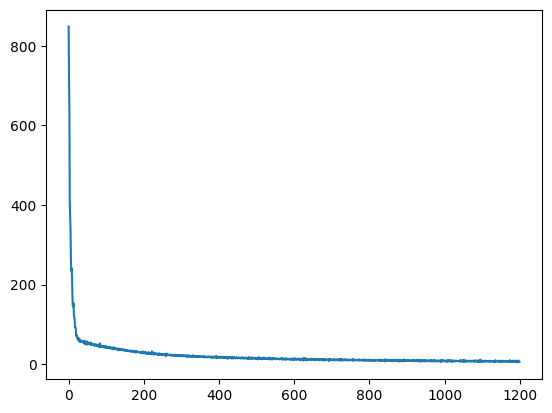

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_arr)
plt.show()

In [ ]:
W1

array([[-0.77978227, -1.15673227, -1.75101301, -1.43805527,  0.20081753,
        -0.72199929, -1.42661453, -1.43937179,  1.74795799,  0.63468998],
       [-0.08834675,  0.02176942, -2.42569773,  0.50585698,  0.36123228,
         0.08941554,  0.26185892, -0.42696486,  0.05857806, -0.80264167],
       [-0.629911  ,  0.60489644, -2.53274462,  1.14786567,  0.30626365,
        -0.5113844 ,  0.28649336,  0.24023137, -0.9420087 ,  1.2498354 ],
       [ 0.8307905 ,  0.33661246, -0.18753853, -0.57183749, -0.76546683,
        -1.49455084, -1.26012137,  0.33702109, -0.86596573,  1.0183546 ]])

In [ ]:
b1

array([[-0.76824527, -0.70717414, -0.56572409, -1.34290533, -0.48100754,
        -0.46216156,  0.15158831, -1.18178345,  0.59266598, -1.57659416]])

In [ ]:
W2

array([[-1.1321912 , -1.09861826,  0.5666117 , -0.33583412],
       [-0.77813484, -0.79113118,  0.38027927, -0.91568549],
       [-0.86827071,  0.3620901 , -1.16111764, -0.77469401],
       [-0.87010906,  0.21461572, -0.74825387, -0.3192252 ],
       [-0.49475613, -0.5701393 , -0.89874864,  0.05536785],
       [-0.5670562 ,  0.65693059,  0.12939742, -1.27263713],
       [-0.57643659, -0.70155653,  0.29340173, -0.34470946],
       [-0.96401653, -0.27600899,  0.33080699, -0.13850356],
       [ 1.15068407,  0.55559094, -1.02538984, -0.18018337],
       [-0.86632953,  0.38102471,  1.59513248, -0.42492802]])

In [ ]:
b2

array([[ 0.0221141 , -0.18518566, -0.13017895, -0.3543131 ]])